# ISO 20414:2020 — Test 12: Stair flow rates

100 occupants funnel through a centred stair opening of width 1.0, 1.2, 1.4, 1.6, 1.8 m (ISO 20414:2020 Table 13). The aim is to confirm that an increase in stair width leads to an increase in agent flow rate. The stair strip carries a **`speed_factor = 0.5` zone** (agents cross it at 0.5 m/s) — the speed-factor convention ISO Test 3/12 describe for stairs. The factor is constant across runs, so width is the only driver of the difference in emergent flow.

In [1]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 30 May 2026, 23:46 UTC


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from jupedsim_scenarios import load_scenario, run_scenario

In [3]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

In [4]:
import json
import tempfile
from scenario_builders.iso12_stair_flow import (
    STAIR_WIDTHS, build_raw_scenario, build_geometry_wkt, measure_flow)

## Sweep stair widths

Each width is materialised as a scenario directory (`config.json` + `geometry.wkt`) and loaded with `load_scenario`.

In [5]:
rows = []
for w in STAIR_WIDTHS:
    raw = build_raw_scenario(w)
    with tempfile.TemporaryDirectory() as d:
        p = Path(d)
        (p / 'config.json').write_text(json.dumps(raw, indent=2), encoding='utf-8')
        (p / 'geometry.wkt').write_text(build_geometry_wkt(w), encoding='utf-8')
        scenario = load_scenario(str(p))
        r = run_scenario(scenario, seed=42)
        rows.append(measure_flow(r.trajectory_dataframe(), r.frame_rate, w))
        r.cleanup()
flow = pd.DataFrame(rows)
flow

,width,crossed,flow_p_s,specific_flow_p_m_s
0,1.0,100,1.194210,1.194210
1,1.2,100,1.420373,1.183644
2,1.4,100,1.715771,1.225551
3,1.6,100,2.028689,1.267930
4,1.8,100,2.214765,1.230425


## Plot flow rate vs stair width

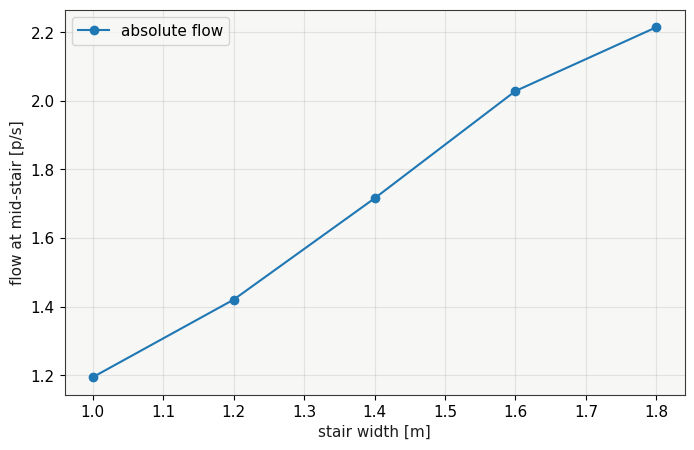

In [6]:
fig, ax = plt.subplots()
ax.plot(flow['width'], flow['flow_p_s'], 'o-', label='absolute flow')
ax.set_xlabel('stair width [m]'); ax.set_ylabel('flow at mid-stair [p/s]')
ax.legend(); plt.show()

## Acceptance

Flow rate should increase with stair width: the widest stair must exceed the narrowest, and the linear trend must have positive slope.

In [7]:
f = flow.dropna(subset=['flow_p_s'])
slope = np.polyfit(f['width'], f['flow_p_s'], 1)[0]
print(f'flow(1.8 m) = {f.flow_p_s.iloc[-1]:.3f} p/s, flow(1.0 m) = {f.flow_p_s.iloc[0]:.3f} p/s, '
      f'slope = {slope:.3f} p/s per m')
assert slope > 0, flow
assert f['flow_p_s'].iloc[-1] > f['flow_p_s'].iloc[0], flow

flow(1.8 m) = 2.215 p/s, flow(1.0 m) = 1.194 p/s, slope = 1.325 p/s per m
